In [ ]:
  import torch
x=torch.tensor([0,1,2,3,4,5], dtype=torch.float)
y=torch.tensor([-1.4,1.4,4.0,7.6,10.1,13.7], dtype=torch.float)

In [ ]:
x=3
y=1
z=3*x**2+4*x*y
print(z)

39


In [ ]:
x=torch.tensor(3.0, requires_grad=True)
y=torch.tensor(1.0, requires_grad=True)
z=3*x**2+4*x*y
print(z)

tensor(39., grad_fn=<AddBackward0>)


In [ ]:
"""import numpy as np
x=np.array([0,1,2,3,4,5])
y=np.array([-1.4,1.4,4.0,7.6,10.1,13.7])
m=0
b=4
y_est=m*x+b
np.sum((y-y_est)**2)
"""

'import numpy as np\nx=np.array([0,1,2,3,4,5])\ny=np.array([-1.4,1.4,4.0,7.6,10.1,13.7])\nm=0\nb=4\ny_est=m*x+b\nnp.sum((y-y_est)**2)\n'

In [ ]:
m=torch.tensor(0, dtype=torch.float32, requires_grad=True)
b=torch.tensor(4, dtype=torch.float32, requires_grad=True)
b

tensor(4., requires_grad=True)

In [ ]:
error=torch.sum((x*m+b-y)**2)
print(error)

tensor(180.1800, grad_fn=<SumBackward0>)


In [ ]:
error.backward()

In [ ]:
print(m.grad, b.grad)


tensor(-162.2000) tensor(-22.8000)


In [ ]:
#proceso iterativo
alfa=0.001
errores=[]
for i in range(20000):
  m.grad.zero_()
  b.grad.zero_()
  error=torch.sum((x*m+b-y)**2)
  error.backward()
  with torch.no_grad():
    m-=alfa*m.grad
    b-=alfa*b.grad
    errores.append(error.item())


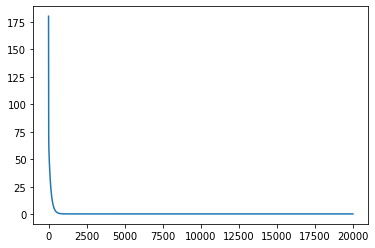

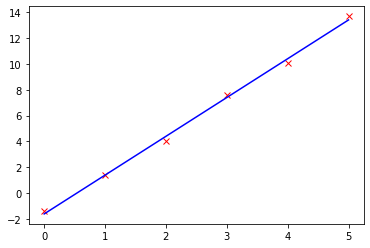

In [ ]:
import matplotlib.pyplot as plt

plt.plot(errores)
plt.figure()
plt.plot(x.numpy(), y.numpy(), 'xr')
with torch.no_grad():
  y_est=x*m+b
  plt.plot(x.numpy(), y_est.numpy(),'-b')